# ESG News Risk Forecaster: Results Walkthrough

This notebook is a clean, presentation-oriented companion to the LaTeX report. It summarizes the data used, the modeling setup, the best results, and the main interpretation using the artifacts already generated by the pipeline.

**Core question:** Can ESG-sensitive news representations improve short-horizon stock-risk forecasting compared with market-only baselines?

**Short answer:** price-history features are very strong; tuned price + ClimateBERT provides the best selected result, but the improvement is modest and should be interpreted cautiously.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Image, Markdown, display

ROOT = Path('..').resolve()
DATA = ROOT / 'data'
OUTPUTS = ROOT / 'outputs'
TABLES = OUTPUTS / 'tables'
FIGURES = OUTPUTS / 'figures'
REPORT_FIGURES = ROOT / 'report' / 'figures'

pd.set_option('display.max_columns', 80)
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')

def show_fig(path, width=900):
    display(Image(filename=str(path), width=width))

## 1. Data Summary

The raw FNSPID news file is large, but the actual supervised ML panel is a weekly ticker panel. One supervised instance is one **ticker-week**.

In [2]:
panel = pd.read_parquet(DATA / 'processed' / 'model_panel_weekly.parquet')
news = pd.read_parquet(DATA / 'interim' / 'news_cleaned_text.parquet')
esg_news = pd.read_parquet(DATA / 'interim' / 'news_esg_keyword_filtered.parquet')
raw_inventory = pd.read_csv(TABLES / 'raw_data_inventory.csv')

signal_cols = [c for c in ['esg_article_count', 'finbert_article_count', 'climate_article_count'] if c in panel.columns]
panel['has_esg_news_week'] = panel[signal_cols].fillna(0).sum(axis=1) >= 1
panel['week_end_date'] = pd.to_datetime(panel['week_end_date'])
news['date'] = pd.to_datetime(news['date'])

summary = pd.DataFrame({
    'Quantity': [
        'Raw FNSPID news file size (GB)',
        'Filtered news articles',
        'ESG keyword-matched articles',
        'Final supervised ML instances (ticker-weeks)',
        'Modeled tickers',
        'ESG/news ticker-weeks',
        'Panel start',
        'Panel end',
    ],
    'Value': [
        float(raw_inventory.loc[raw_inventory['item'].eq('news_csv_gb'), 'value'].iloc[0]),
        len(news),
        int(esg_news['is_esg_keyword_article'].sum()),
        len(panel),
        panel['ticker'].nunique(),
        int(panel['has_esg_news_week'].sum()),
        panel['week_end_date'].min().date(),
        panel['week_end_date'].max().date(),
    ]
})
summary

,Quantity,Value
0,Raw FNSPID news file size (GB),23.2330
1,Filtered news articles,112807
2,ESG keyword-matched articles,22965
3,Final supervised ML instances (ticker-weeks),5852
4,Modeled tickers,14
5,ESG/news ticker-weeks,2748
6,Panel start,2016-01-01
7,Panel end,2023-12-29


### Key dataset takeaway

The project processed over **100k filtered articles**, but after aggregation and label construction the actual ML dataset contains **5,852 ticker-week instances**. This is appropriate for a panel forecasting project, but it is not a massive supervised learning dataset after weekly aggregation.

## 2. Data Diagnostics

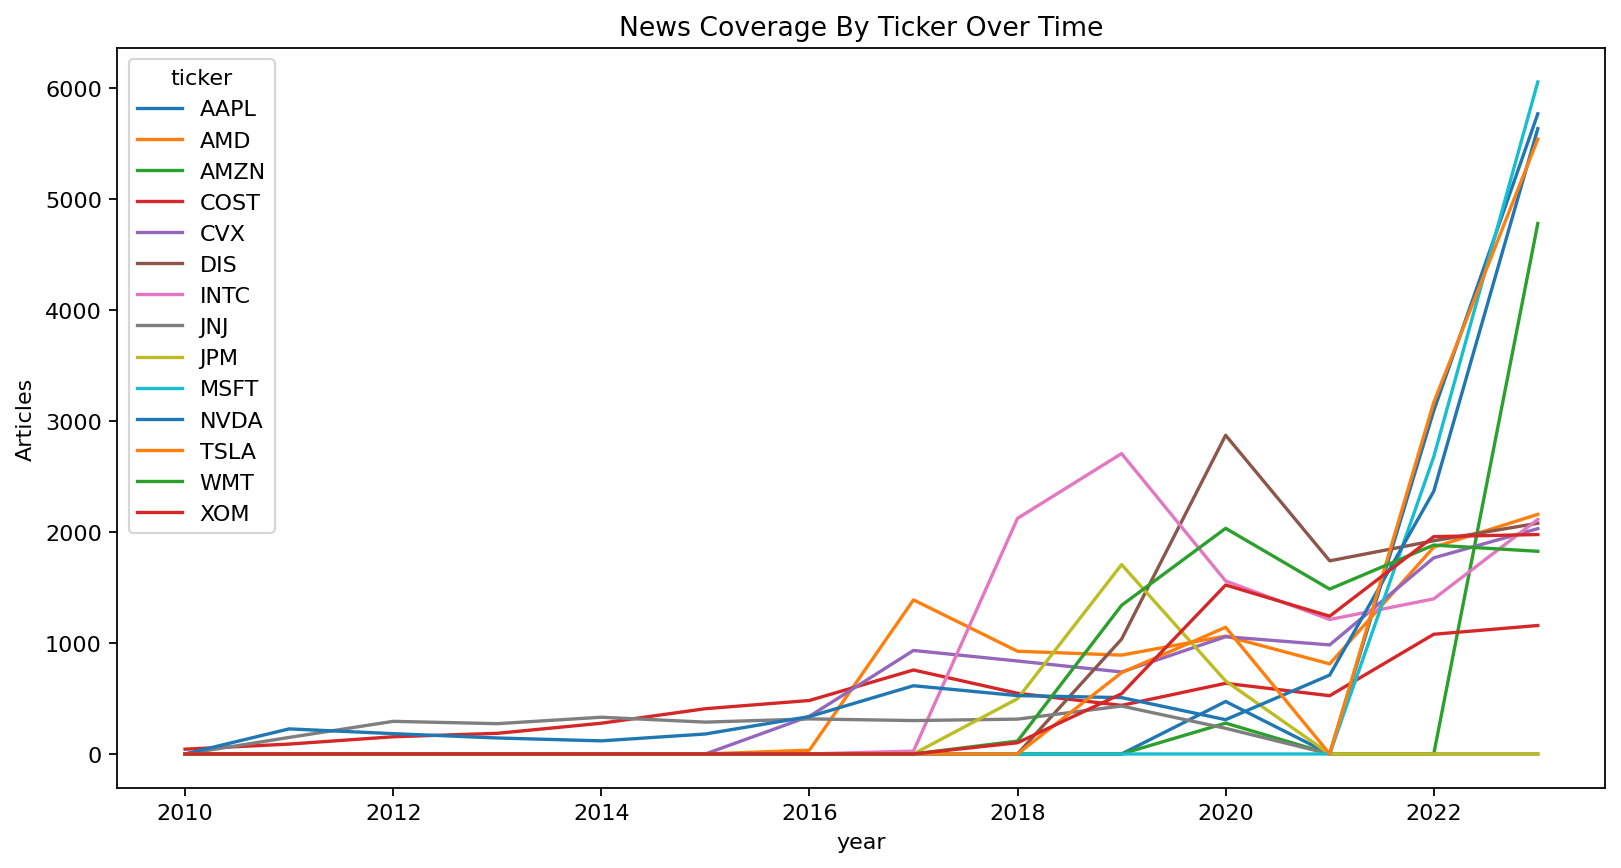

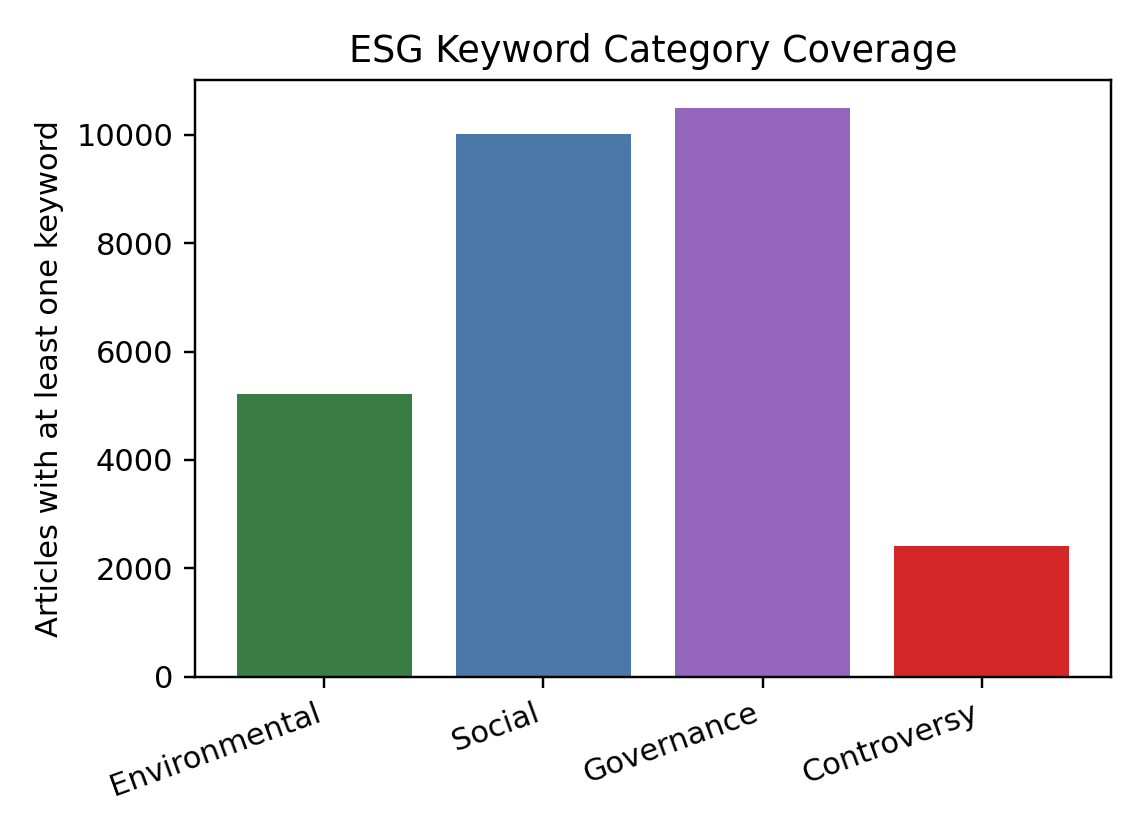

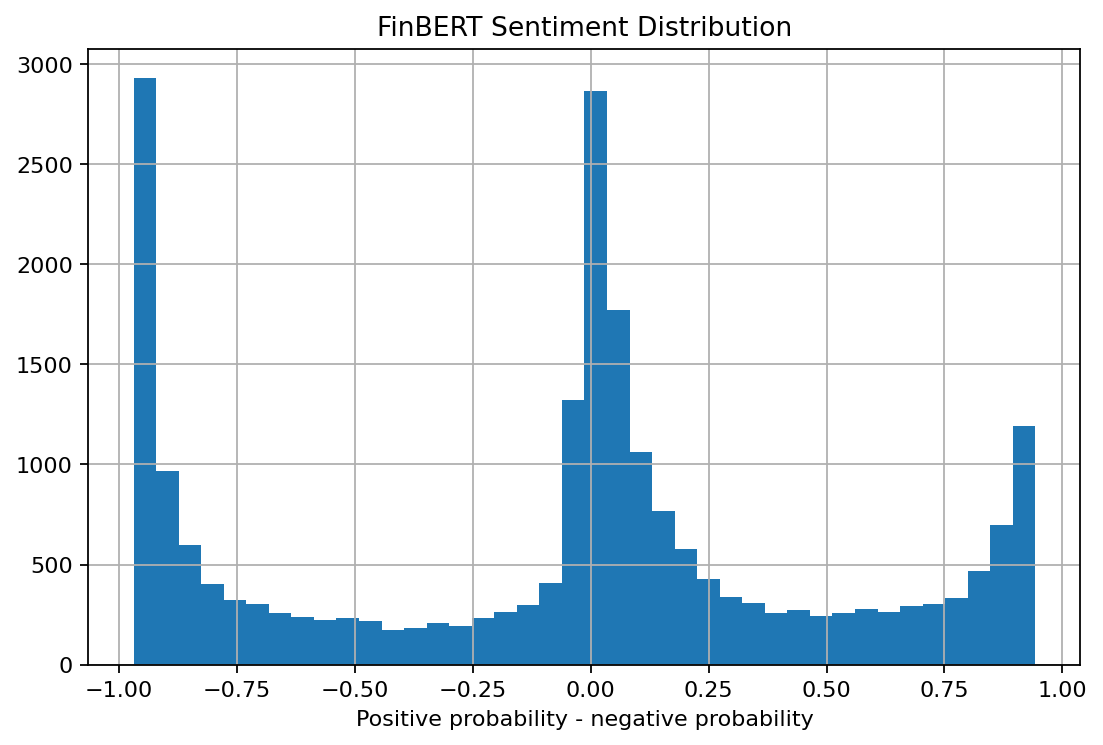

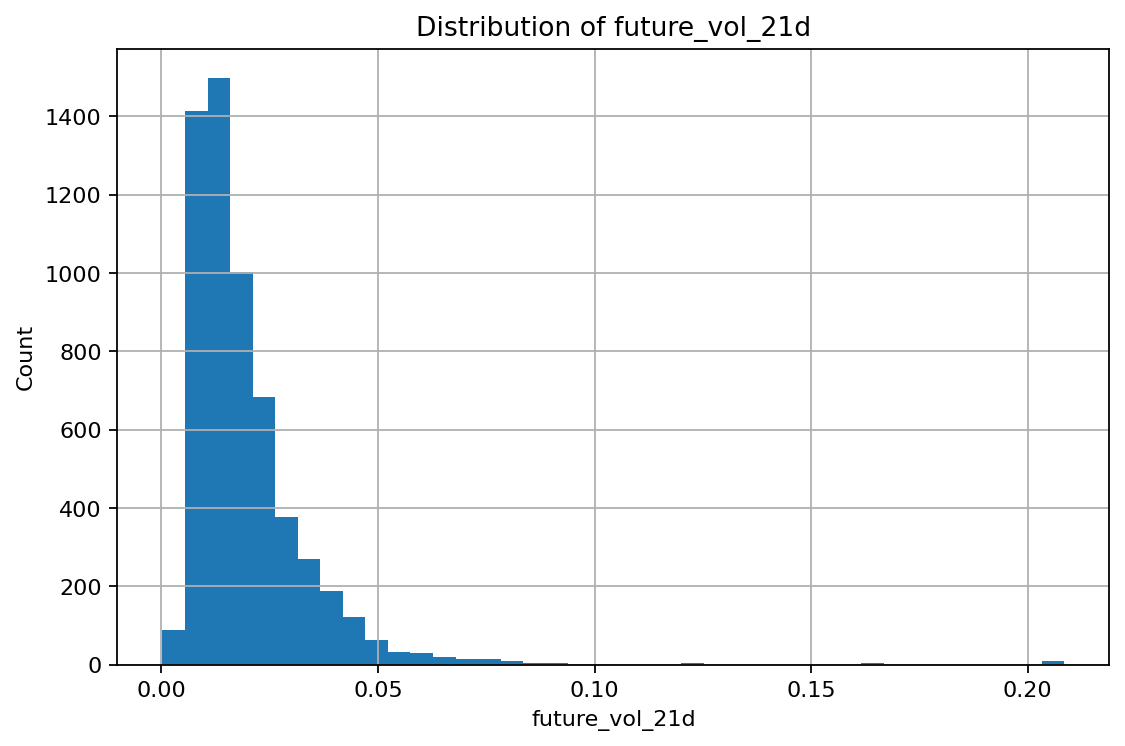

In [3]:
show_fig(REPORT_FIGURES / 'dataset_distribution.png', width=900)
show_fig(REPORT_FIGURES / 'esg_category_distribution.png', width=700)
show_fig(REPORT_FIGURES / 'sentiment_distribution.png', width=700)
show_fig(REPORT_FIGURES / 'risk_label_distribution.png', width=700)

The data diagnostics show three important points:

1. News coverage is uneven across tickers and years.
2. ESG keyword filtering gives interpretable article groups, but keyword matching is noisy.
3. Future realized volatility is right-skewed, so the classification task is a useful complement to regression.

## 3. Modeling Setup

The pipeline uses a chronological split to reduce lookahead bias:

- **Train:** 2016-2021
- **Validation:** 2022
- **Test:** 2023

Targets:

- Regression: future 21-trading-day realized volatility.
- Classification: top-quartile high-volatility ticker-weeks.

Feature groups:

- Price-only baseline.
- ESG keyword features.
- FinBERT sentiment features.
- ClimateBERT relevance features.
- Combined price + news feature groups.

In [4]:
split_counts = pd.Series({
    'train_2016_2021': int(((panel['week_end_date'] >= '2016-01-01') & (panel['week_end_date'] <= '2021-12-31')).sum()),
    'validation_2022': int(((panel['week_end_date'] >= '2022-01-01') & (panel['week_end_date'] <= '2022-12-31')).sum()),
    'test_2023': int((panel['week_end_date'] >= '2023-01-01').sum()),
    'test_2023_news_weeks': int(((panel['week_end_date'] >= '2023-01-01') & panel['has_esg_news_week']).sum()),
}).rename('rows').to_frame()
split_counts

,rows
train_2016_2021,4396
validation_2022,728
test_2023,728
test_2023_news_weeks,591


## 4. Best Tuned Test Results

In [5]:
tuned_metrics = pd.read_csv(TABLES / 'tuned_model_metrics.csv')

reg = tuned_metrics.query("evaluation_slice == 'all_weeks' and task == 'regression'").copy()
clf = tuned_metrics.query("evaluation_slice == 'all_weeks' and task == 'classification'").copy()

best_reg = reg.loc[reg.groupby('feature_group')['rmse'].idxmin()].sort_values('rmse')
best_clf = clf.loc[clf.groupby('feature_group')['roc_auc'].idxmax()].sort_values('roc_auc', ascending=False)

display(Markdown('### Best regression model by feature group'))
display(best_reg[['feature_group', 'model', 'test_rows', 'rmse', 'mae', 'r2', 'spearman']])

display(Markdown('### Best classification model by feature group'))
display(best_clf[['feature_group', 'model', 'test_rows', 'roc_auc', 'pr_auc', 'f1', 'precision_at_top_10pct']])

### Best regression model by feature group

,feature_group,model,test_rows,rmse,mae,r2,spearman
58,price_climatebert,hist_gradient_boosting,728,0.0063,0.0047,0.5240,0.7962
42,price,hist_gradient_boosting,728,0.0064,0.0048,0.5042,0.7841
34,full,hist_gradient_boosting,728,0.0065,0.0049,0.4971,0.7831
50,price_all_news,hist_gradient_boosting,728,0.0065,0.0049,0.4971,0.7831


### Best classification model by feature group

,feature_group,model,test_rows,roc_auc,pr_auc,f1,precision_at_top_10pct
26,price_climatebert,hist_gradient_boosting,728,0.9144,0.8515,0.8019,0.9589
2,full,hist_gradient_boosting,728,0.9134,0.8362,0.7770,0.9178
18,price_all_news,hist_gradient_boosting,728,0.9134,0.8362,0.7770,0.9178
10,price,hist_gradient_boosting,728,0.9123,0.8414,0.7982,0.9041


### Main result

The tuned **price + ClimateBERT** model is the best selected configuration in both tasks:

- Regression RMSE: **0.00631** vs. **0.00644** for tuned price-only.
- Classification ROC-AUC: **0.914** vs. **0.912** for tuned price-only.

The improvement is real in the selected run, but modest. The correct interpretation is that ESG/climate text adds incremental context, not that it replaces price-history features.

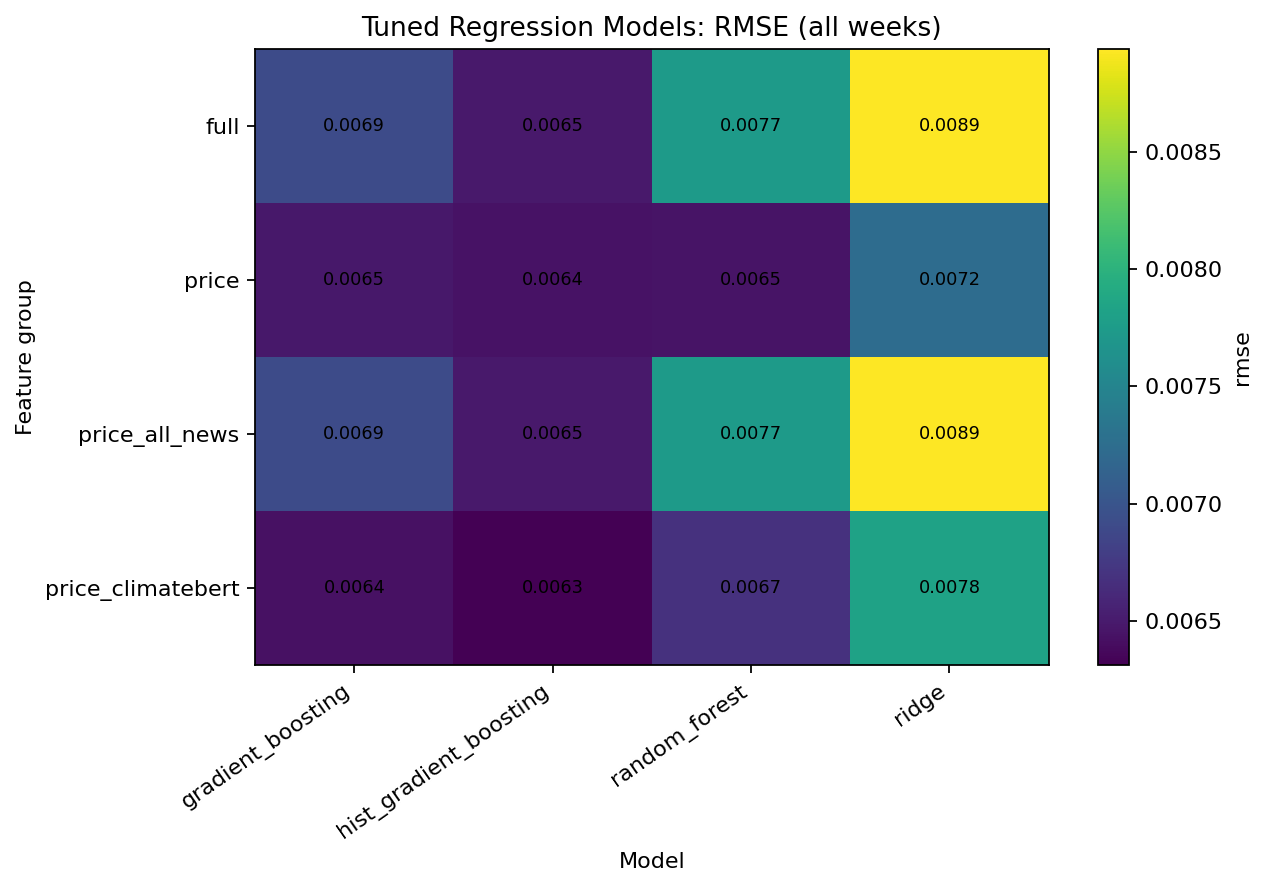

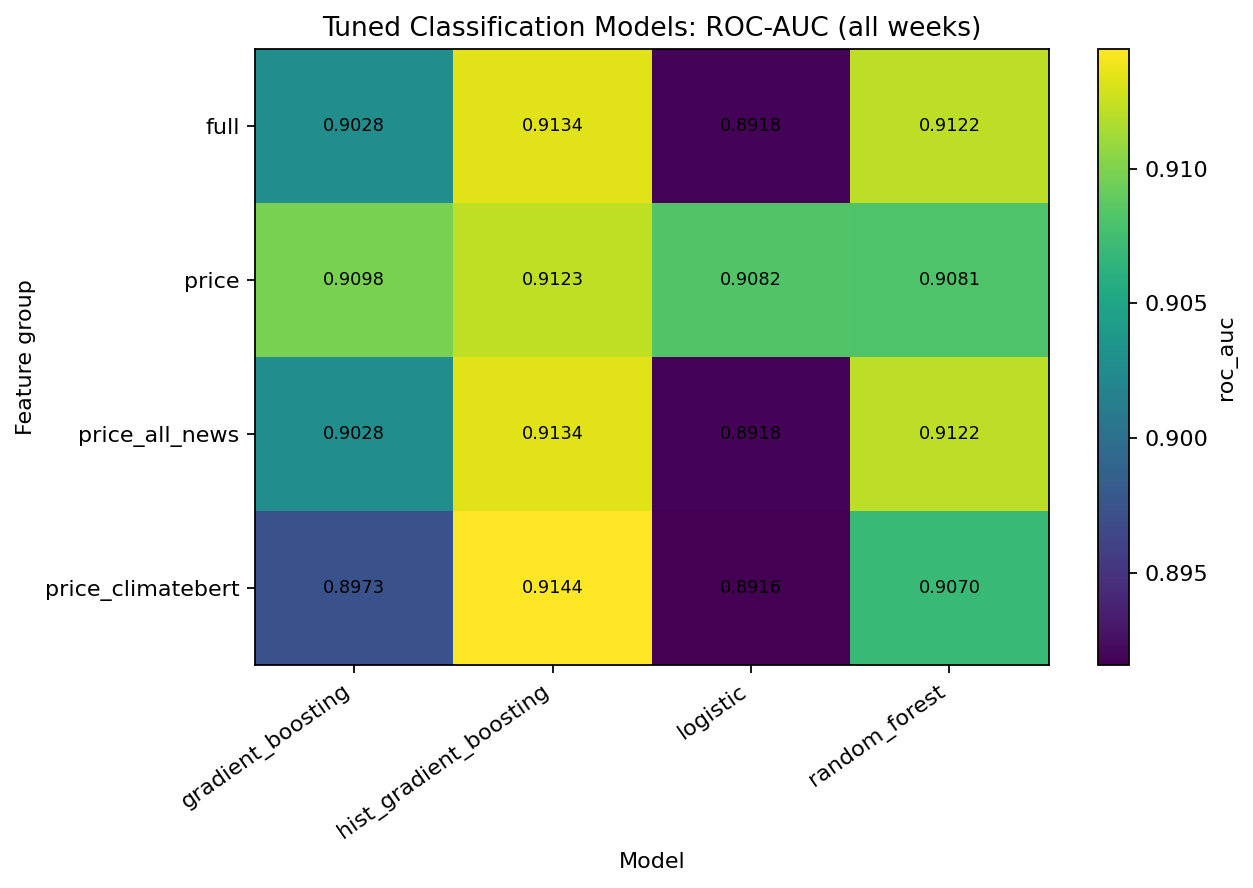

In [6]:
show_fig(REPORT_FIGURES / 'model_performance_regression.png', width=900)
show_fig(REPORT_FIGURES / 'model_performance_classification.png', width=900)

## 5. Ablation Against Price-Only Baseline

In [7]:
groups = ['price', 'price_climatebert', 'price_all_news', 'full']
reg_best = best_reg.set_index('feature_group').loc[groups]
clf_best = best_clf.set_index('feature_group').loc[groups]

ablation = pd.DataFrame({
    'rmse': reg_best['rmse'],
    'delta_rmse_vs_price': reg_best.loc['price', 'rmse'] - reg_best['rmse'],
    'roc_auc': clf_best['roc_auc'],
    'delta_auc_vs_price': clf_best['roc_auc'] - clf_best.loc['price', 'roc_auc'],
})
ablation

,rmse,delta_rmse_vs_price,roc_auc,delta_auc_vs_price
feature_group,,,,
price,0.0064,0.0000,0.9123,0.0000
price_climatebert,0.0063,0.0001,0.9144,0.0021
price_all_news,0.0065,-0.0000,0.9134,0.0011
full,0.0065,-0.0000,0.9134,0.0011


Ablation takeaway: adding all news features is not automatically better. The best combined result is the more targeted **price + ClimateBERT** feature set.

## 6. Classification Diagnostics

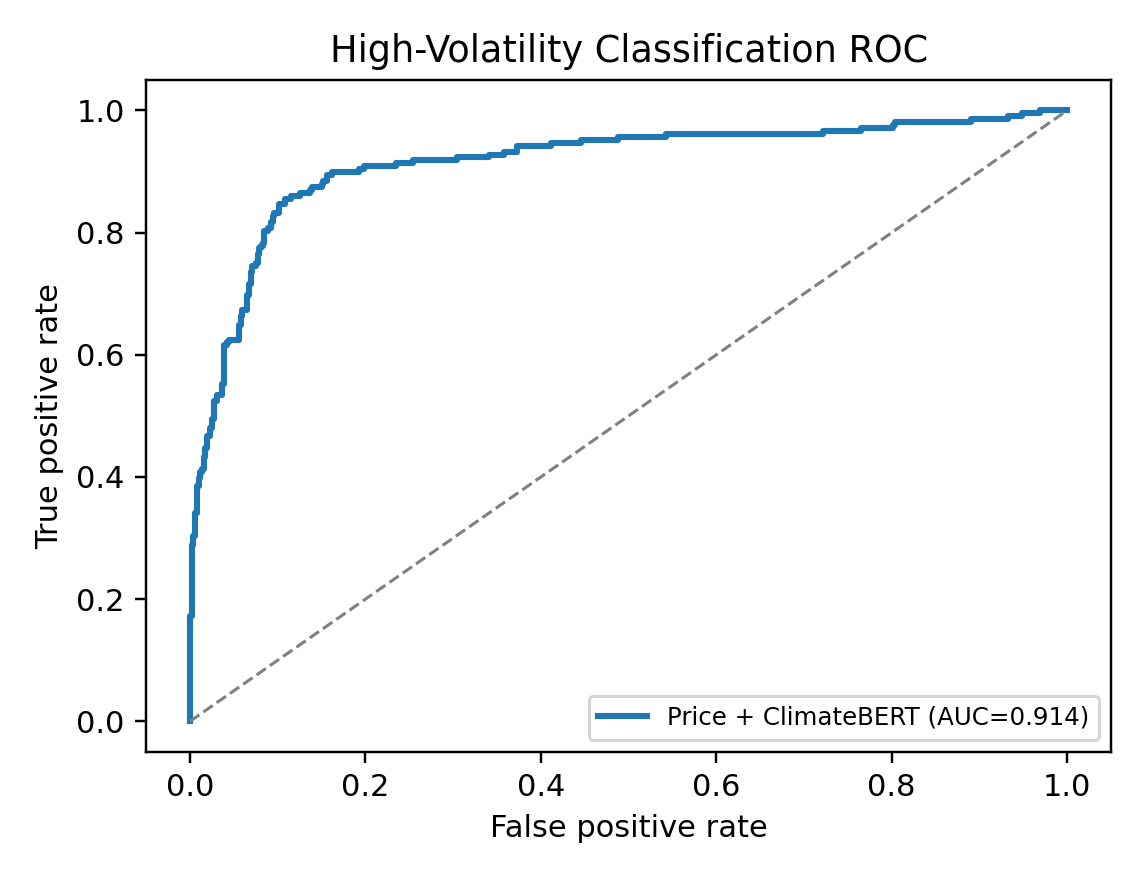

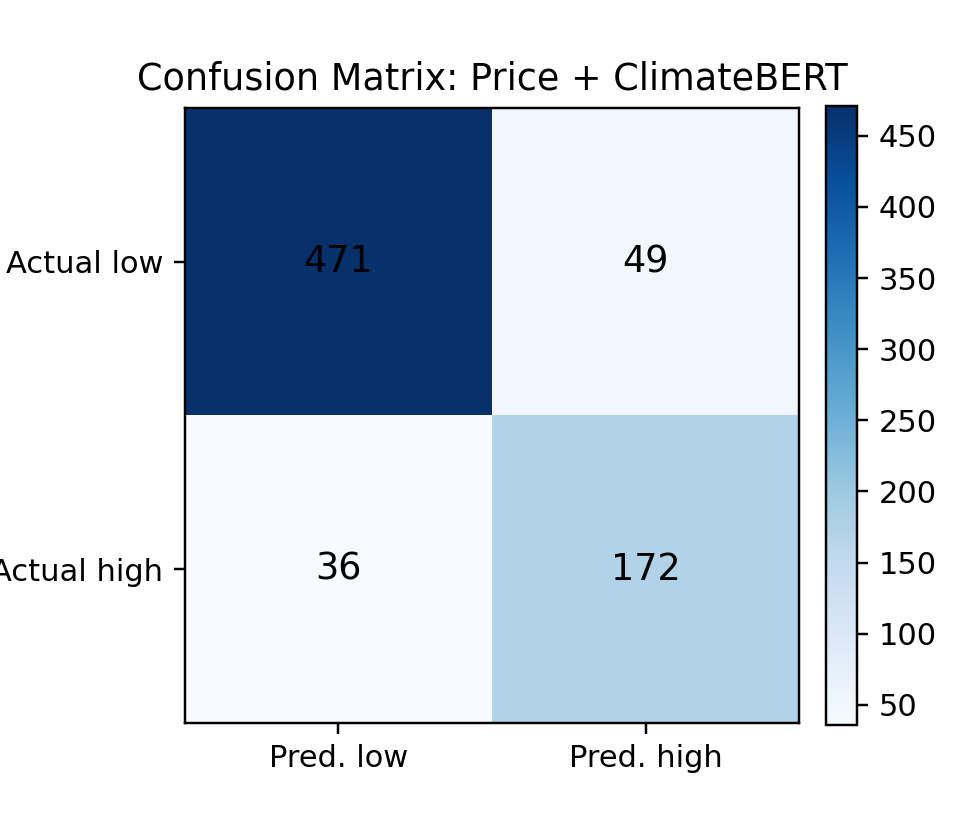

In [8]:
show_fig(REPORT_FIGURES / 'roc_curve.png', width=650)
show_fig(REPORT_FIGURES / 'confusion_matrix.png', width=550)

The ROC curve is the better diagnostic for this project because risk screening is usually a ranking problem: an analyst cares about which ticker-weeks are highest risk, not only whether a fixed 0.5 threshold is crossed.

## 7. Regression and Ranking Diagnostics

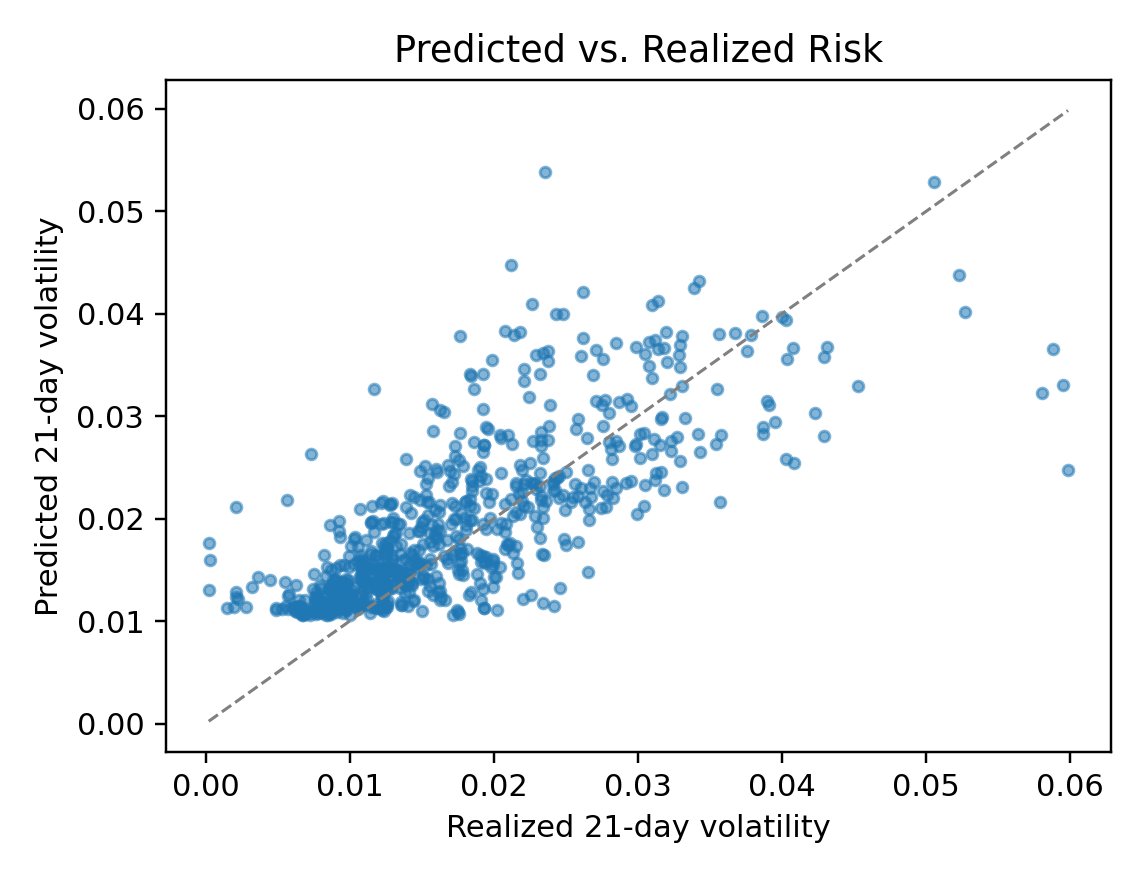

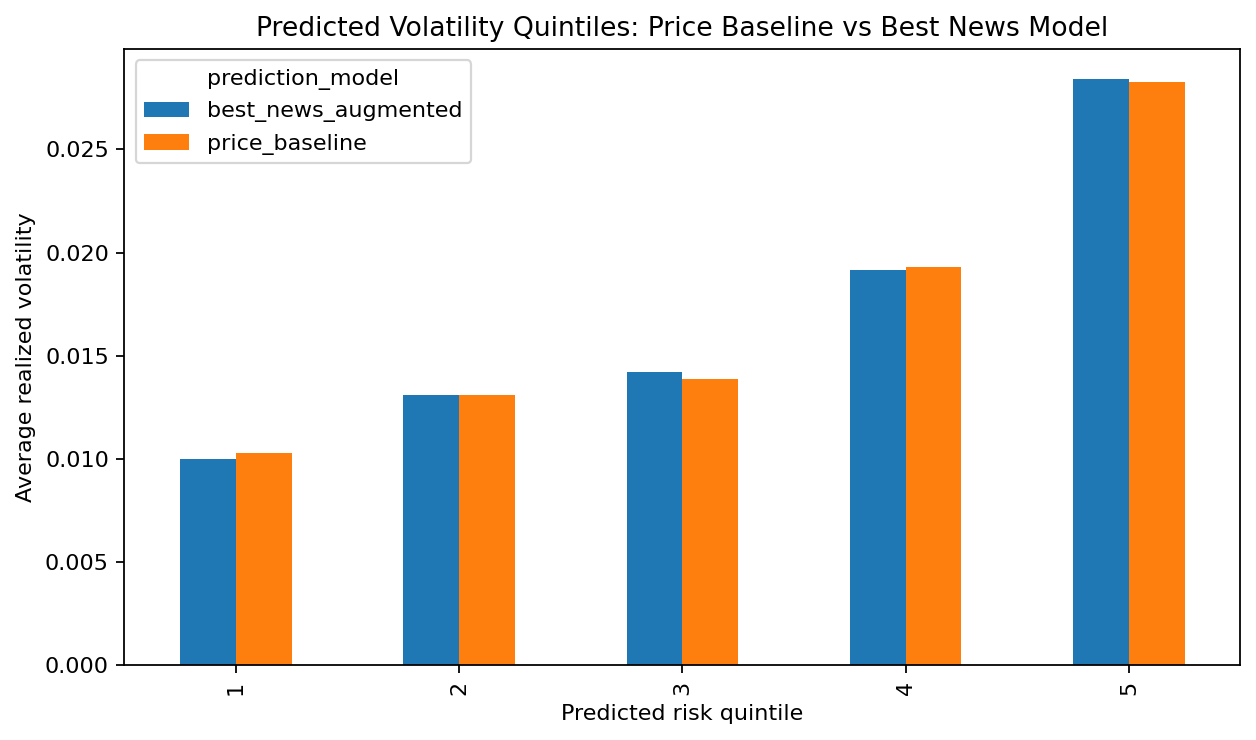

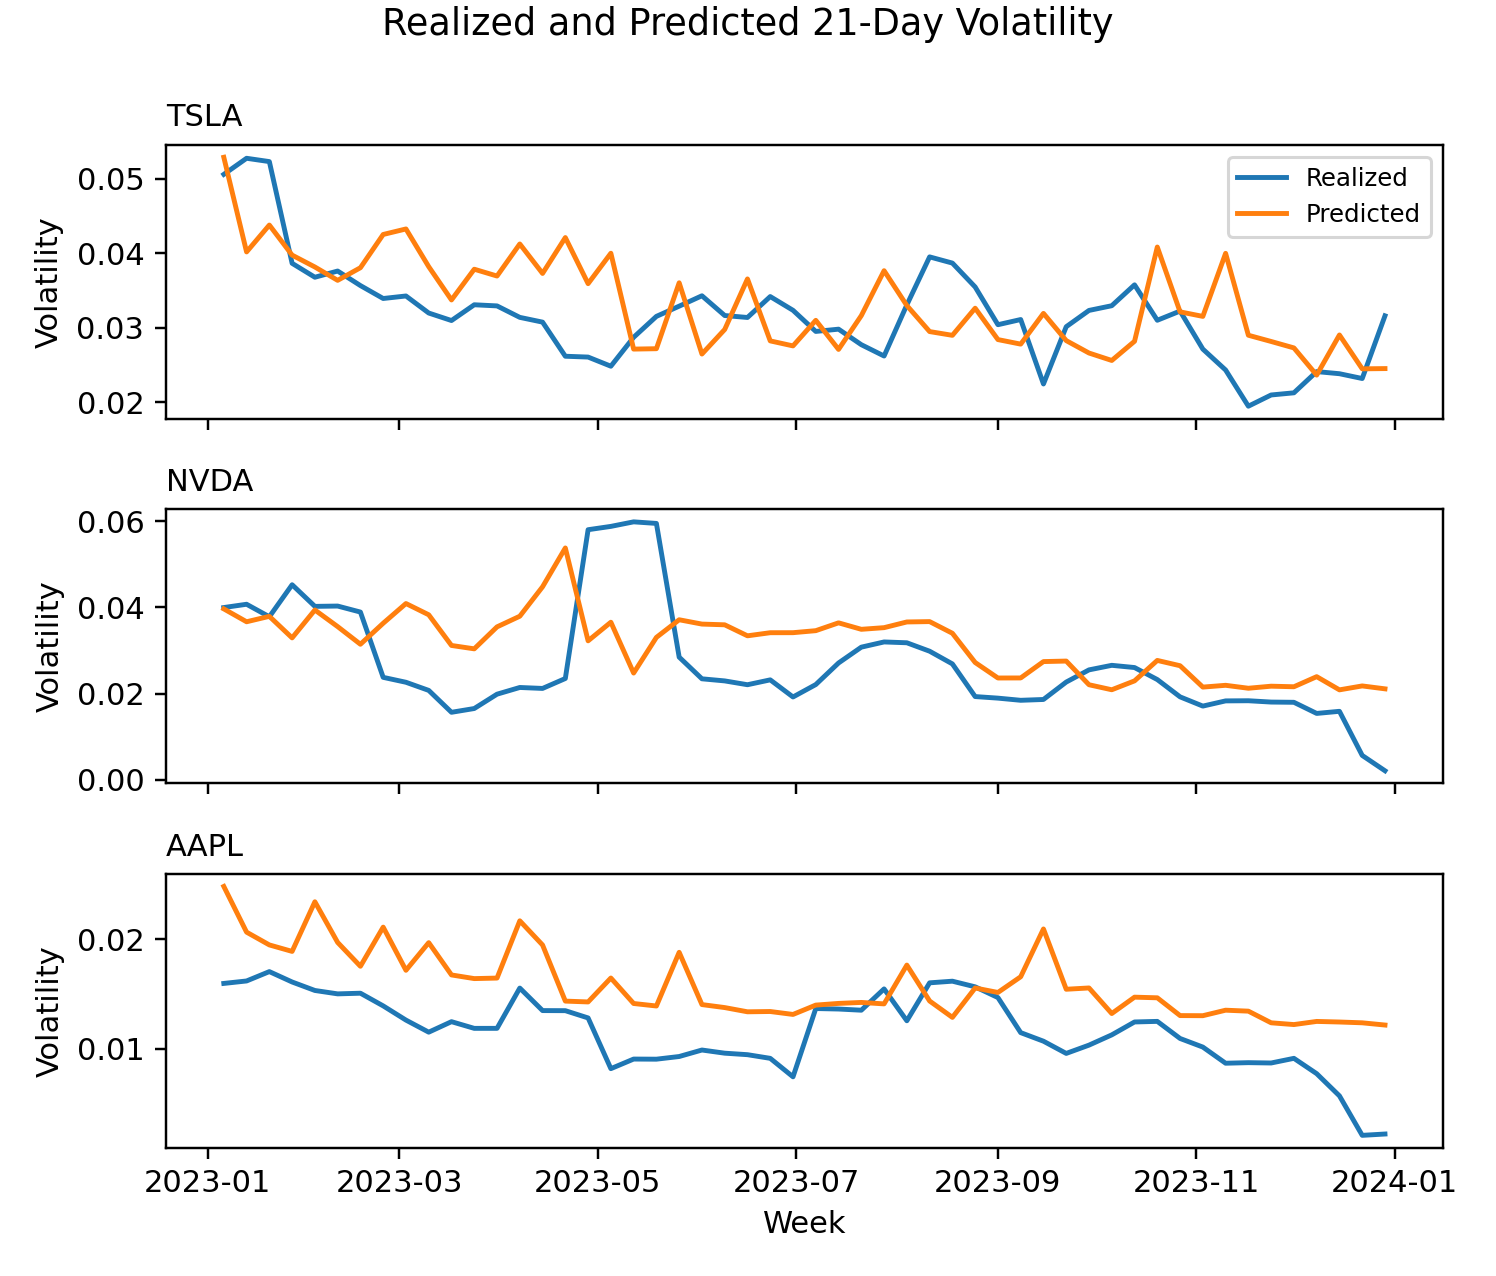

In [9]:
show_fig(REPORT_FIGURES / 'predicted_vs_realized_risk.png', width=650)
show_fig(REPORT_FIGURES / 'quintile_realized_volatility.png', width=750)
show_fig(REPORT_FIGURES / 'timeseries_predicted_realized_risk.png', width=900)

The quintile plot is one of the most useful sanity checks: realized volatility increases monotonically from low predicted-risk quintiles to high predicted-risk quintiles. This suggests the model is useful for **ranking** risk, even when point forecasts remain noisy.

## 8. Feature Associations

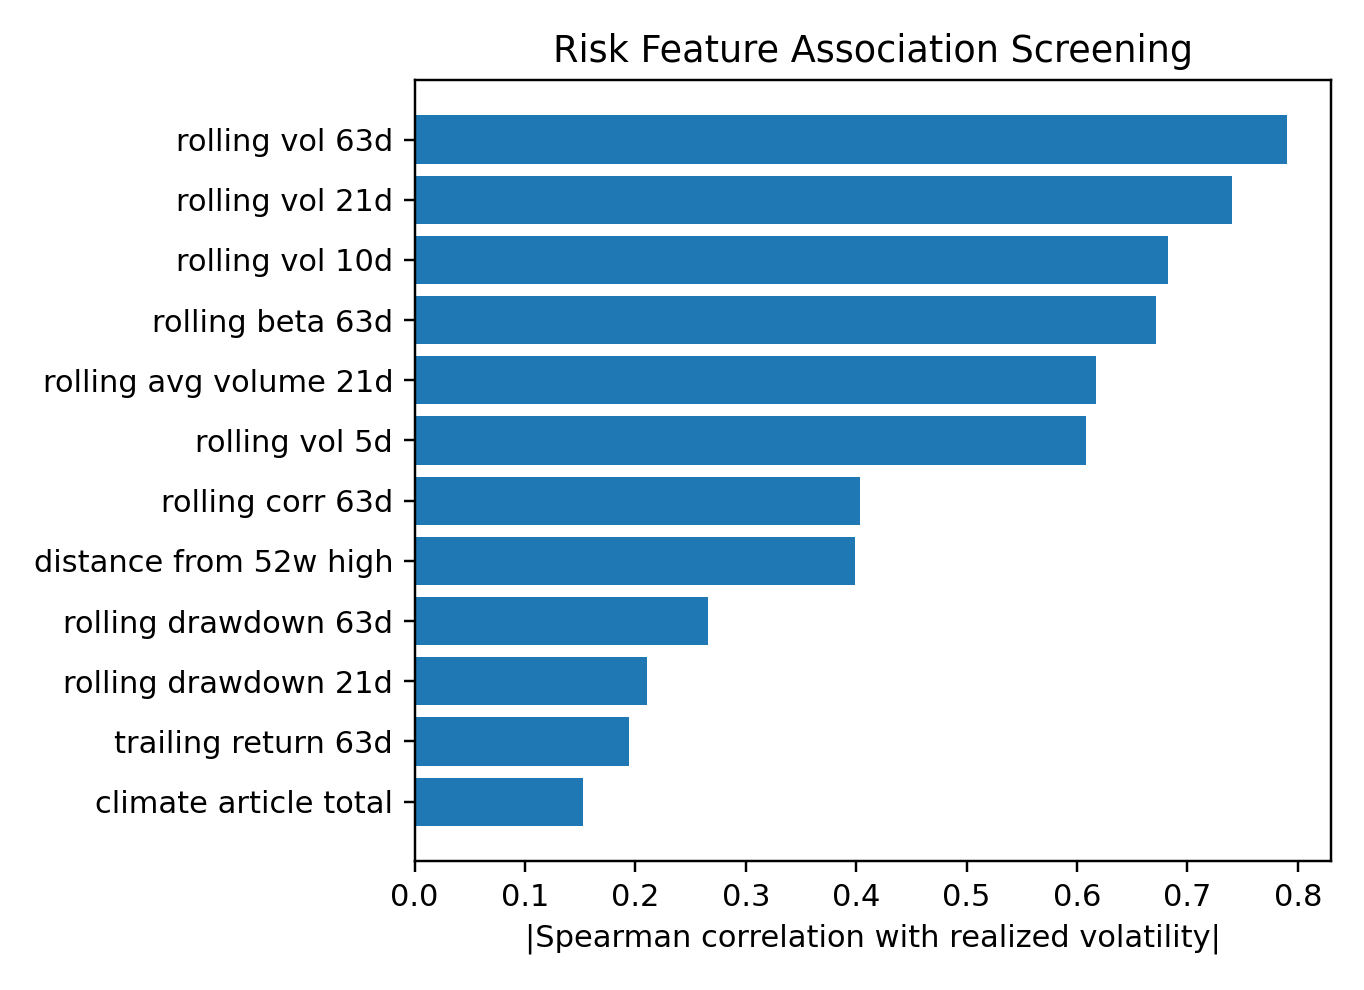

In [10]:
show_fig(REPORT_FIGURES / 'feature_importance.png', width=800)

This feature association plot is not SHAP and not a model-internal importance measure. It is a transparent correlation-style diagnostic. The main point is that market-risk features remain central, while climate-aware text contributes as an additional contextual signal.

## 9. Final Interpretation

The project supports a cautious conclusion:

- Price-history features are hard to beat for volatility forecasting.
- News-only models are not competitive with market-only baselines.
- ESG keyword and sentiment features are useful but noisy.
- ClimateBERT appears to add the clearest incremental value when combined with price features.
- The evidence is predictive, not causal.

For a sustainable-investing or risk-monitoring workflow, the best framing is: **ESG news signals enrich a price-based risk model, but should not replace it.**